In [ ]:
import os


os.environ['USER'] = 'shaans321'
os.environ['REPO'] = 'shaans-ml'
os.environ['TOKEN'] = '****'

# do everything in colab's "root" directory
%cd /content
!git clone https://${TOKEN}@github.com/${USER}/${REPO}.git

# make sure your repo shows up
%ls

/content
Cloning into 'dl-hw'...
remote: Enumerating objects: 51858, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 51858 (delta 8), reused 8 (delta 5), pack-reused 51842 (from 5)
Receiving objects: 100% (51858/51858), 561.36 MiB | 20.86 MiB/s, done.
Resolving deltas: 100% (2595/2595), done.
Updating files: 100% (70258/70258), done.
dl-hw/  sample_data/


In [2]:
%cd /content/{os.environ['REPO']}
%ls

# go to a specific homework
#%mkdir -p aih-hrp/
%cd aih-hrp/
%ls


/content/dl-hw
aih-hrp/  Homework/
/content/dl-hw/aih-hrp
Classifier_Muradataset_20250413_1epoch.th  mura_resnet18_for_ELBOW_DS.pt
Classifier.th                              mura_resnet18_fulldataset25epo.pt
metrics_train.json                         mura_resnet18.pt
model.py                                   train.py
mura_dataset                               utils.py
mura_dataset.py


In [3]:
HOMEWORK_DIR='/content/dl-hw/aih-hrp'

In [ ]:
# refreshes python imports automatically when you edit the source file
# %load_ext autoreload
# %autoreload 2

Data Setup

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11")

print("Path to dataset files:", path)
root_path = path

Using Colab cache for faster access to the 'mura-v11' dataset.
Path to dataset files: /kaggle/input/mura-v11


In [ ]:
print(path)

/kaggle/input/mura-v11


In [5]:
# list files from path

import os

# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
if 'path' in locals():
  for filename in os.listdir(path):
    print(f"{path=}")
    print(f"{filename}")

else:
  print("Error: 'path' variable not found. Please run the kagglehub dataset download code first.")


path='/kaggle/input/mura-v11'
MURA_fn_dev.csv
path='/kaggle/input/mura-v11'
MURA_fn_train.csv
path='/kaggle/input/mura-v11'
MURA-v1.1
path='/kaggle/input/mura-v11'
phase_1_resnet_mon_jun_26_23-28-30_2023.pt


In [ ]:
for filename in os.listdir(path):
  print(f"{path=}")
  print(f"{filename}")

path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
phase_1_resnet_mon_jun_26_23-28-30_2023.pt
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_dev.csv
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA-v1.1
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_train.csv


In [6]:
import pandas as pd
df_train_labeled_studies = pd.read_csv(os.path.join(path, "MURA-v1.1/MURA-v1.1/train_labeled_studies.csv"))
df_train_labeled_studies.head(2)

,MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/,1
0,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1
1,MURA-v1.1/train/XR_SHOULDER/patient00003/study...,1


In [ ]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "MURA_fn_dev.csv"))
print(f"{df.head()=}")  # Print first few rows to verify
print(f"{df.shape=}")
print(f"{df.info()=}")
print(f"{df.describe()=}")


df.head()=   Unnamed: 0.1  Unnamed: 0  \
0          1941        1941   
1          2333        2333   
2          4447        4447   
3            58          58   
4          1258        1258   

                                                path  Split      Bone  \
0  MURA-v1.1\train\XR_ELBOW\patient05290\study1_p...  train  XR_ELBOW   
1  MURA-v1.1\train\XR_ELBOW\patient05413\study1_p...  train  XR_ELBOW   
2  MURA-v1.1\train\XR_ELBOW\patient06185\study1_n...  train  XR_ELBOW   
3  MURA-v1.1\train\XR_ELBOW\patient00370\study1_n...  train  XR_ELBOW   
4  MURA-v1.1\train\XR_ELBOW\patient05067\study1_p...  train  XR_ELBOW   

        Patient       FolderName   Study     Label  
0  patient05290  study1_positive  study1  positive  
1  patient05413  study1_positive  study1  positive  
2  patient06185  study1_negative  study1  negative  
3  patient00370  study1_negative  study1  negative  
4  patient05067  study1_positive  study1  positive  
df.shape=(3680, 9)
<class 'pandas.core.frame.D

In [ ]:
df.describe()

,Unnamed: 0.1,Unnamed: 0
count,3680.000000,3680.000000
mean,18497.421467,18497.421467
std,10716.242913,10716.242913
min,5.000000,5.000000
25%,9280.250000,9280.250000
50%,18459.000000,18459.000000
75%,27659.500000,27659.500000
max,36806.000000,36806.000000


In [7]:
import pandas as pd
df_MURA_fn_dev = pd.read_csv(os.path.join(path, "MURA_fn_dev.csv"))
df_MURA_fn_dev.head(2)

,Unnamed: 0.1,Unnamed: 0,path,Split,Bone,Patient,FolderName,Study,Label
0,1941,1941,MURA-v1.1\train\XR_ELBOW\patient05290\study1_p...,train,XR_ELBOW,patient05290,study1_positive,study1,positive
1,2333,2333,MURA-v1.1\train\XR_ELBOW\patient05413\study1_p...,train,XR_ELBOW,patient05413,study1_positive,study1,positive


In [ ]:
df_MURA_fn_dev['Label'].value_counts()

,count
Label,
negative,2225
positive,1455


In [ ]:
# Total number of images
total_images = len(df_MURA_fn_dev)
print(f"Total number of images in df_MURA_fn_dev: {total_images}")


Total number of images in df_MURA_fn_dev: 3680


In [ ]:
df_MURA_fn_dev['Label'].value_counts()

,count
Label,
negative,2225
positive,1455


In [ ]:
#MURA stats

import pandas as pd

# Number of unique patients
unique_patients = df_MURA_fn_dev['Patient'].nunique()
print(f"Number of unique patients: {unique_patients}")

# Image stats by bone and label
image_stats = df_MURA_fn_dev.groupby(['Bone', 'Label']).size().unstack(fill_value=0)
print("\nImage stats by bone and label:")
image_stats

Number of unique patients: 3190

Image stats by bone and label:


Label,negative,positive
Bone,,
XR_ELBOW,281,212
XR_FINGER,318,193
XR_FOREARM,105,77
XR_HAND,406,148
XR_HUMERUS,73,54
XR_SHOULDER,436,402
XR_WRIST,606,369


In [8]:
df_MURA_fn_train = pd.read_csv(os.path.join(path, "MURA_fn_train.csv"))

In [ ]:
# Total number of images
total_images = len(df_MURA_fn_train)
print(f"Total number of images in df_MURA_fn_train: {total_images}")

Total number of images in df_MURA_fn_train: 33128


In [ ]:
df_MURA_fn_train.head(2)

,Unnamed: 0.1,Unnamed: 0,path,Split,Bone,Patient,FolderName,Study,Label
0,0,0,MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...,train,XR_ELBOW,patient00011,study1_negative,study1,negative
1,1,1,MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...,train,XR_ELBOW,patient00011,study1_negative,study1,negative


In [ ]:
# Count matching 'path' column values
matching_paths = df_MURA_fn_train['path'].isin(df_MURA_fn_dev['path']).sum()
print(f"Number of matching paths: {matching_paths}")

Number of matching paths: 0


In [ ]:
#list of all subdirectories and files from path,"MURA-v1.1"

import os
print(f"{path=}")
def list_files_and_subdirectories(path):
  """Lists all subdirectories and files from the given path."""
  if not os.path.exists(path):
      print(f"Error: Path '{path}' does not exist.")
      return
  i=0
  for root, dirs, files in os.walk(path):
      level = root.replace(path, '').count(os.sep)
      indent = ' ' * 4 * (level)
      #print('{}{}/'.format(indent, os.path.basename(root)))
      subindent = ' ' * 4 * (level + 1)
      full_path = os.path.join(path, root)
      #print(full_path)
      i+=1
      if i==10:
        break
      for f in files:
          #print('{}{}'.format(subindent, f))
          print(full_path+"/"+f)
          break

# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
if 'path' in locals():
  list_files_and_subdirectories(path)
else:
  print("Error: 'path' variable not found. Please run the kagglehub dataset download code first.")


path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/phase_1_resnet_mon_jun_26_23-28-30_2023.pt
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid_labeled_studies.csv
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid/XR_FINGER/patient11946/study2_negative/image1.png
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid/XR_FINGER/patient11946/study1_negative/image1.png


/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid/XR_HAND/patient11583/study1_negative/image4.png


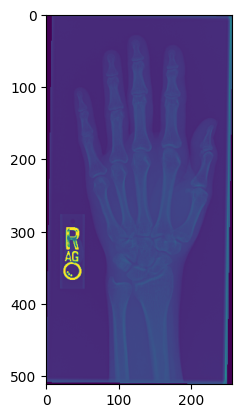

torch.Size([512, 258])
torch.Size([512, 258])
torch.float32
torch.Size([512, 258]) torch.Size([512, 258]) torch.float32


/tmp/ipykernel_5048/1032678373.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(img1)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch

#file1=os.path.join(path,"MURA-v1.1","/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient02008/study1_negative/image1.png")
#file1=os.path.join(path,"MURA-v1.1","train/XR_SHOULDER/patient02008/study1_negative/image1.png")
#print(f"{file1=}")
#/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1\train\XR_ELBOW\patient05290\study1_positive\image1.png
#/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient02008/study1_negative/image1.png
#/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/mura-v11/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image1.png
#file1='/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/valid/XR_WRIST/patient11268/study1_positive/image1.png'
file1='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid/XR_HAND/patient11583/study1_negative/image4.png'
print(file1)
# Read and display the image
plt.imshow(mpimg.imread(file1))
plt.show()

img1=torch.tensor(mpimg.imread(file1))
print(img1.shape)
print(img1.size())
print(img1.dtype)
img_tensor = torch.tensor(img1)
print(img_tensor.shape, img_tensor.size(), img_tensor.dtype)

Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image3.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00016/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00016/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00026/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00026/study1_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00026/study1_negative/image3.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBO

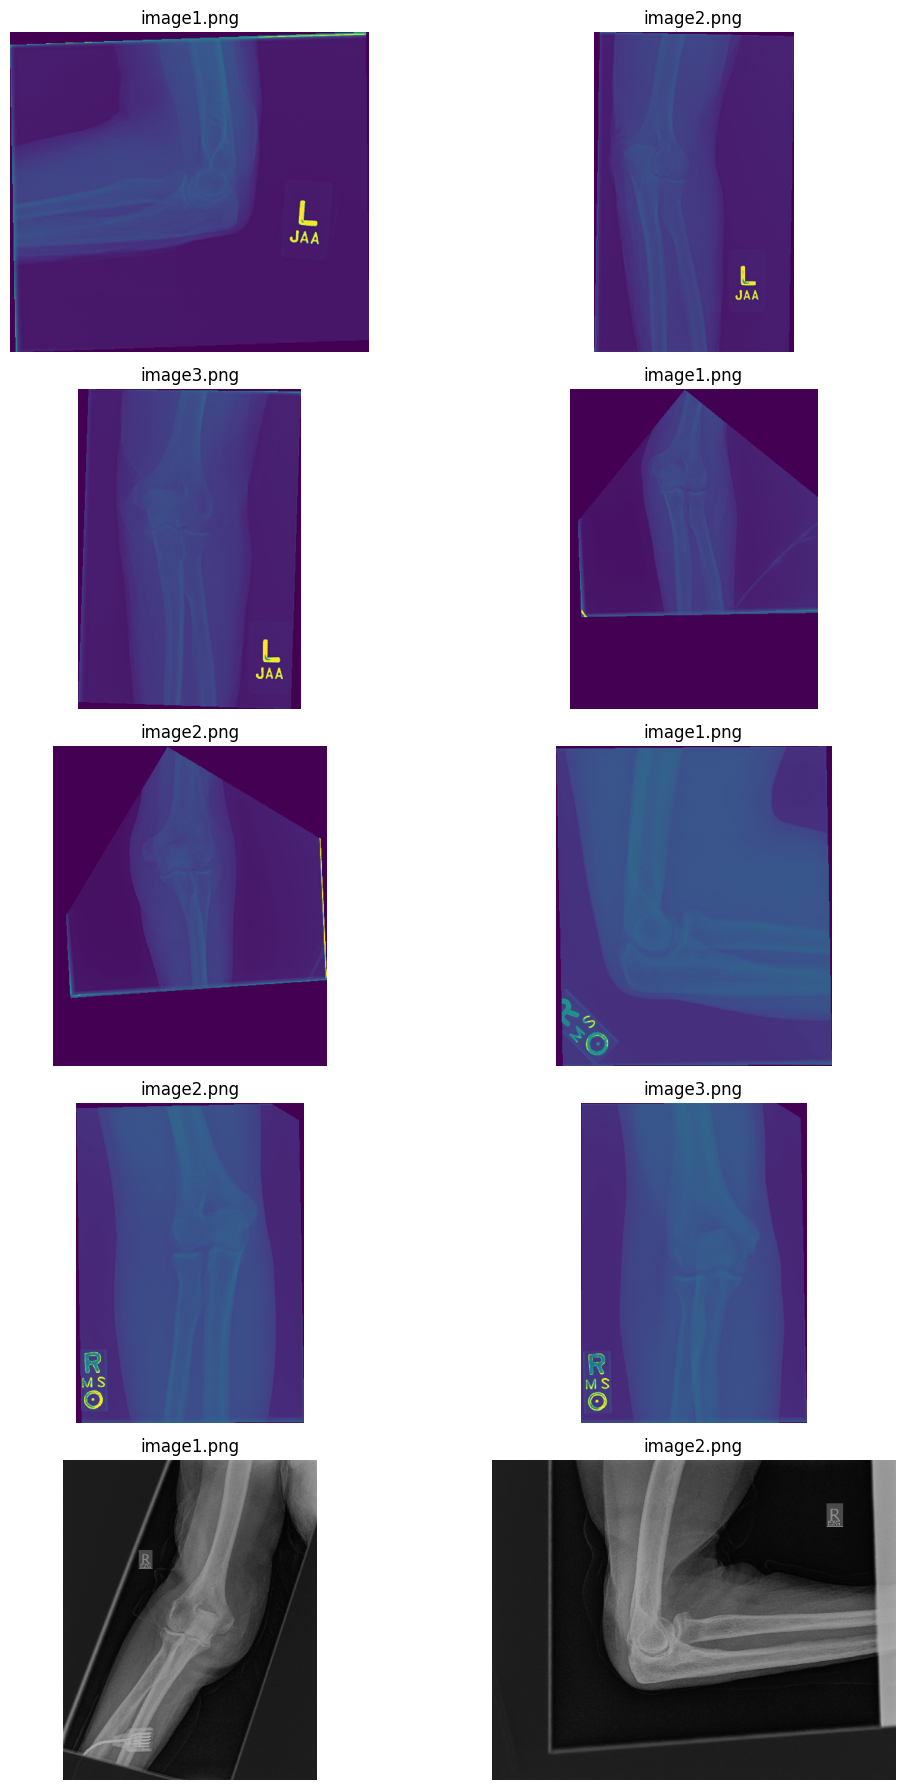

In [9]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

def plot_images(image_paths, rows=5, cols=2):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 18))  # Adjust figsize as needed
    axes = axes.ravel()  # Flatten the axes array for easy iteration
    for i, image_path in enumerate(image_paths):
      print(axes[i].set_title(image_path))
    for i, image_path in enumerate(image_paths):
        if i >= rows * cols:
            break  # Stop if we've filled all the subplots
        try:
            img = mpimg.imread(image_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(image_path))  # Set title to filename
            #axes[i].set_title(image_path)  # Set title to filename
            axes[i].axis('off') # Hide axes
        except FileNotFoundError:
            print(f"Error: File not found - {image_path}")
        except Exception as e:
            print(f"Error displaying image {image_path}: {e}")

    plt.tight_layout()  # Adjust layout to prevent overlapping titles
    plt.show()


# Example usage: Plot the first 10 images from df_MURA_fn_dev
if 'df_MURA_fn_train' in locals() and 'path' in locals():
    image_paths = [os.path.join(path,'MURA-v1.1', p.replace("\\", "/")) for p in df_MURA_fn_train['path'][0:10]]
    plot_images(image_paths)

else:
    print("Error: 'df_MURA_fn_dev' or 'path' variable not found. Please run the necessary code cells first.")



--- Displaying images for Bone: XR_ELBOW ---
Positive Studies for XR_ELBOW:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00016/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00016/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00034/study1_positive/image2.png')


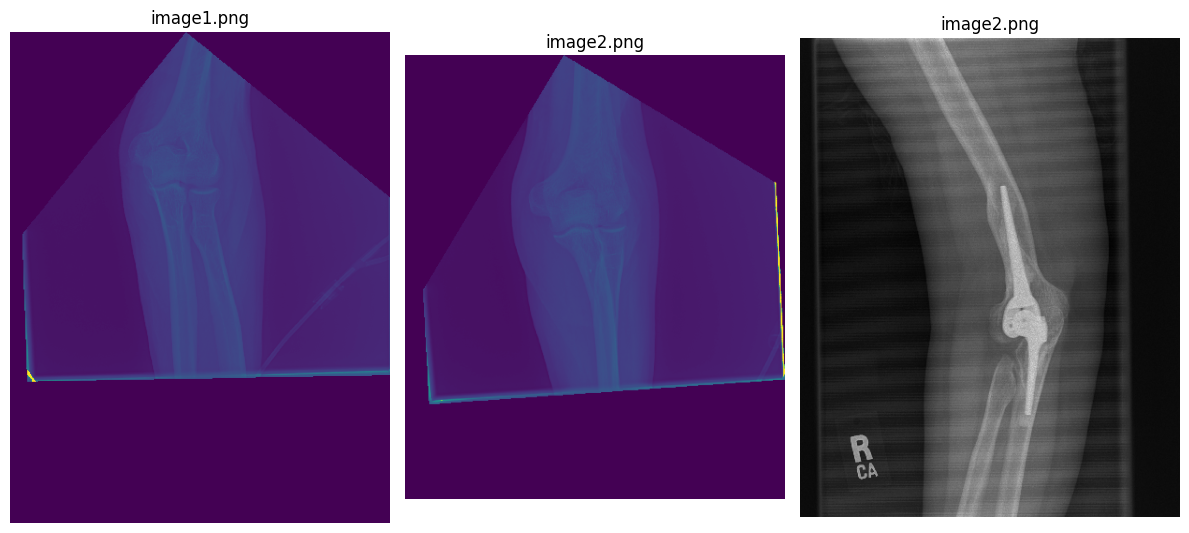

Negative Studies for XR_ELBOW:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image3.png')


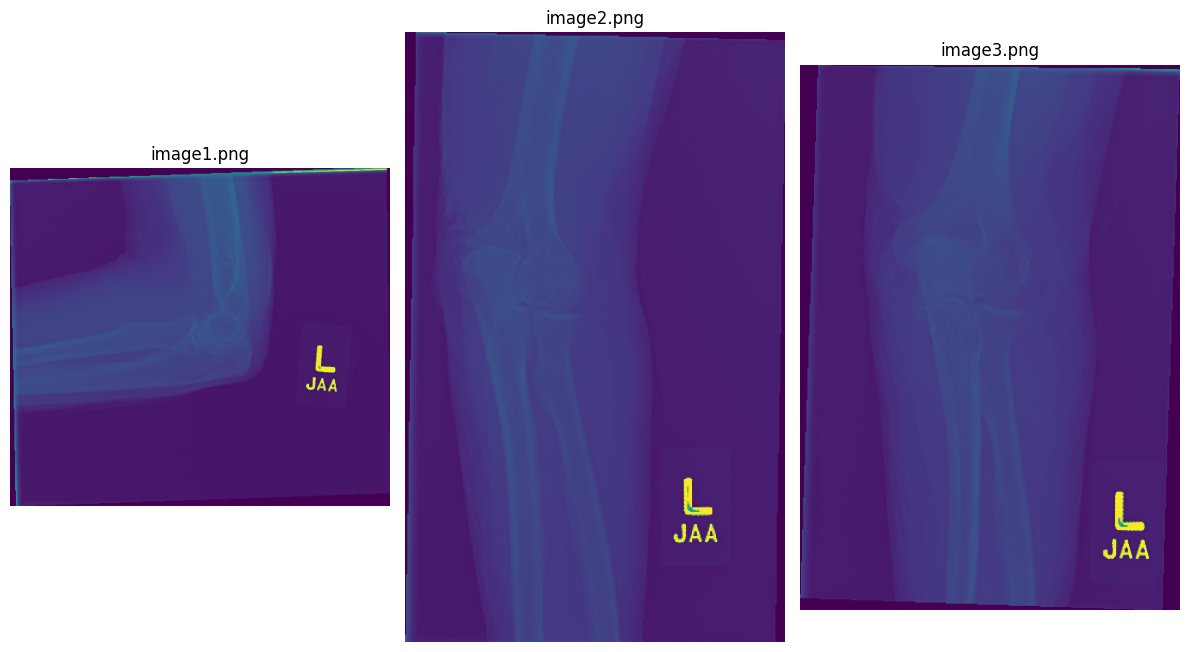


--- Displaying images for Bone: XR_FINGER ---
Positive Studies for XR_FINGER:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FINGER/patient00042/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FINGER/patient00042/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FINGER/patient00042/study1_positive/image3.png')


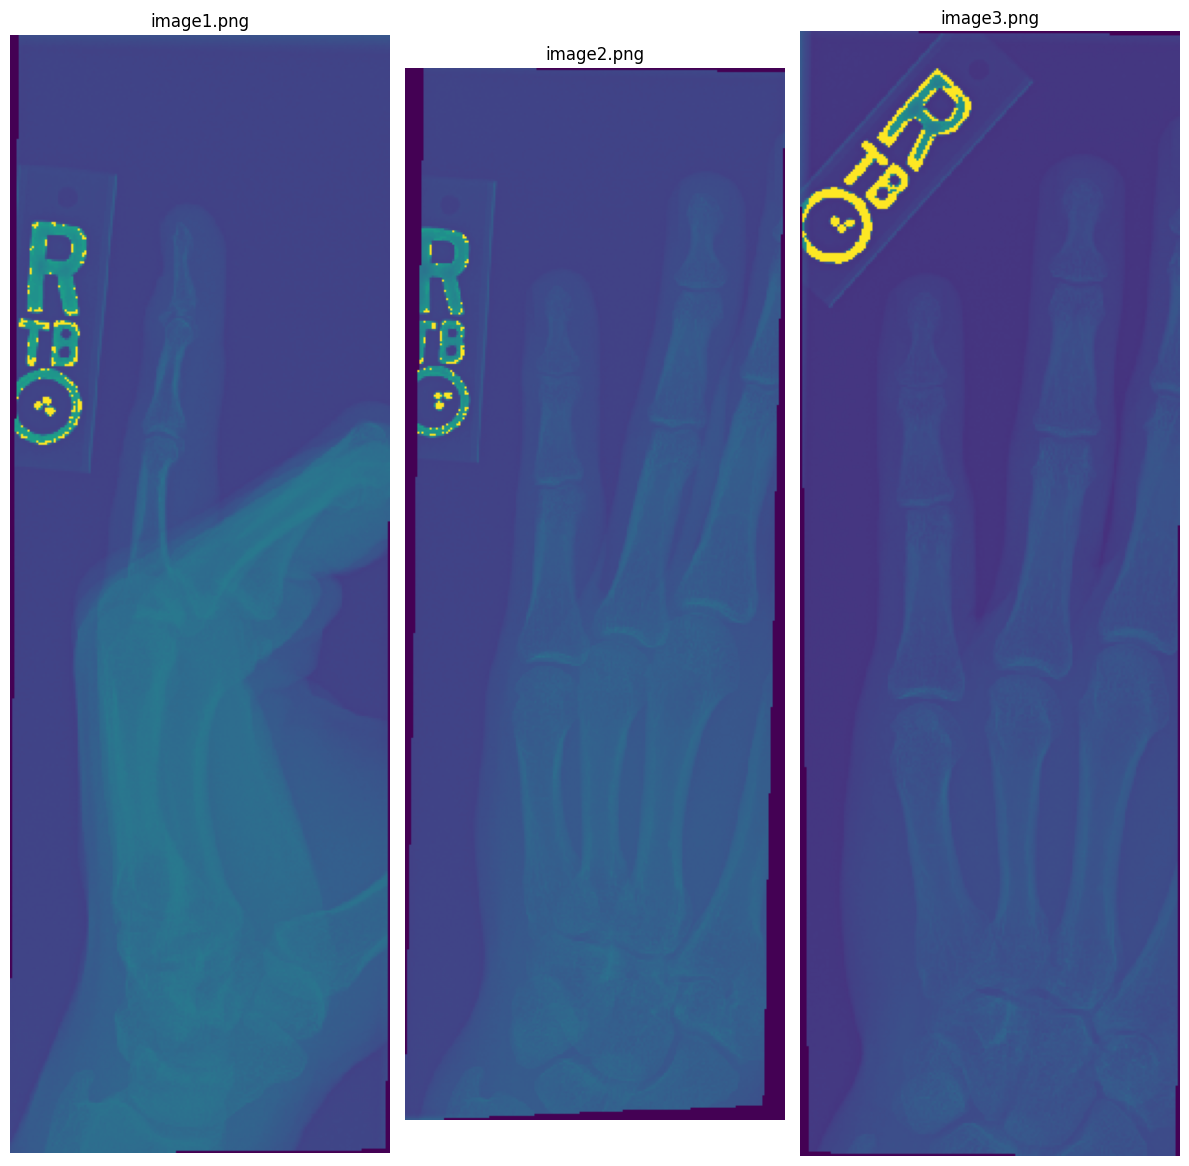

Negative Studies for XR_FINGER:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FINGER/patient00011/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FINGER/patient00114/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FINGER/patient00114/study1_negative/image2.png')


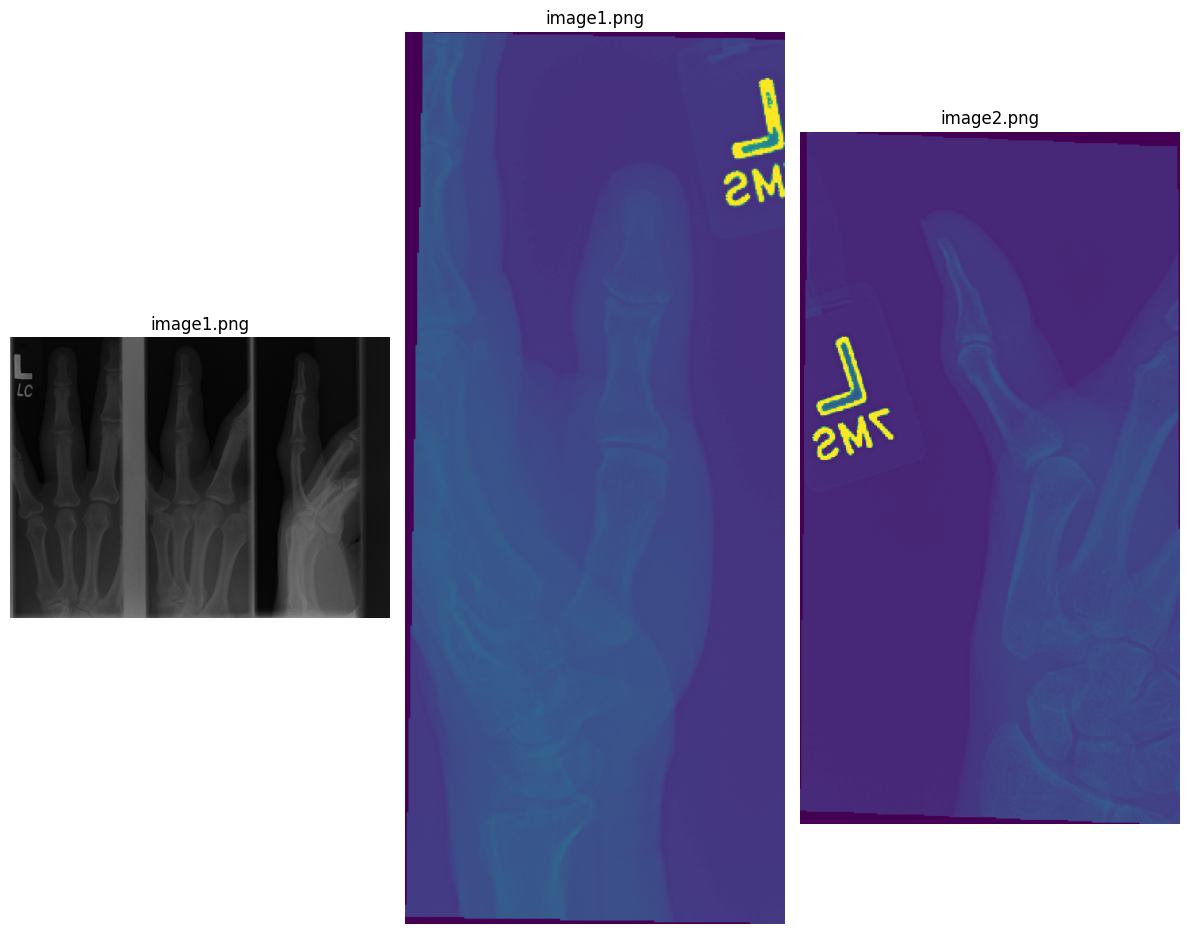


--- Displaying images for Bone: XR_FOREARM ---
Positive Studies for XR_FOREARM:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient00063/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient00063/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient00297/study1_positive/image1.png')


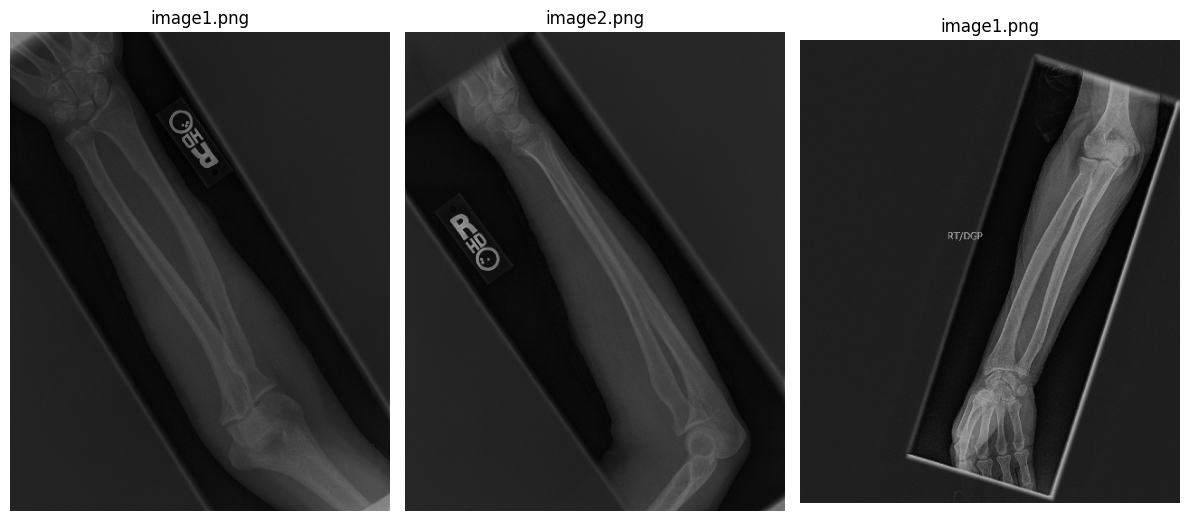

Negative Studies for XR_FOREARM:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient00067/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient00069/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient00069/study1_negative/image2.png')


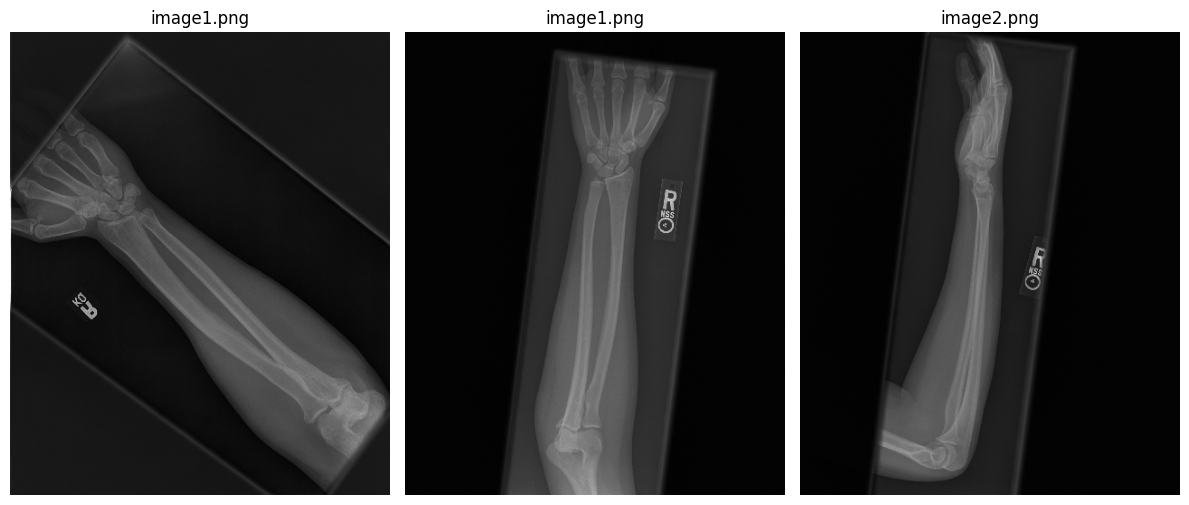


--- Displaying images for Bone: XR_HAND ---
Positive Studies for XR_HAND:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HAND/patient00008/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HAND/patient00008/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HAND/patient00008/study1_positive/image3.png')


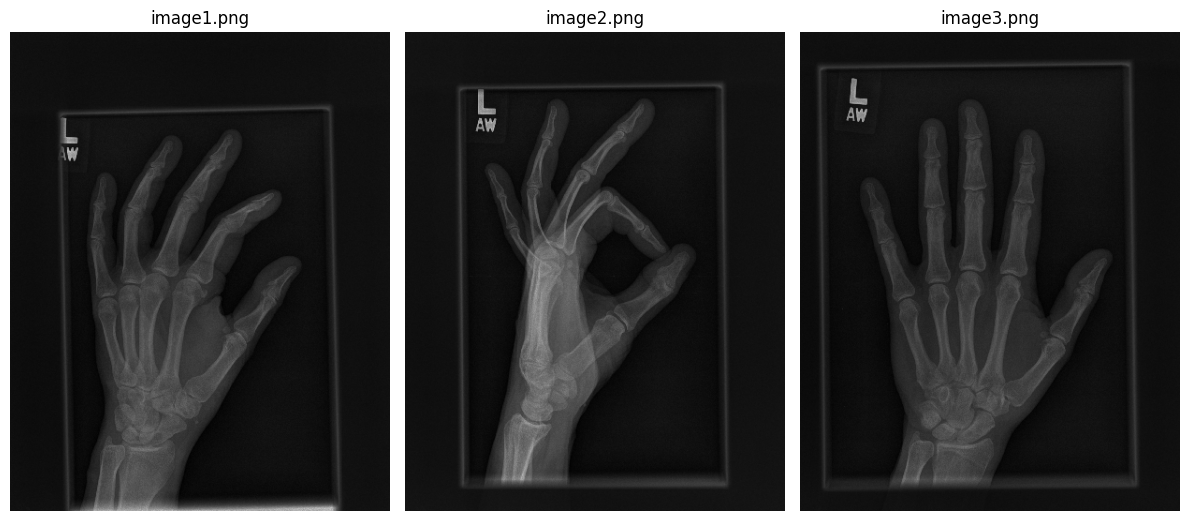

Negative Studies for XR_HAND:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HAND/patient00050/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HAND/patient00050/study1_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HAND/patient00050/study1_negative/image3.png')


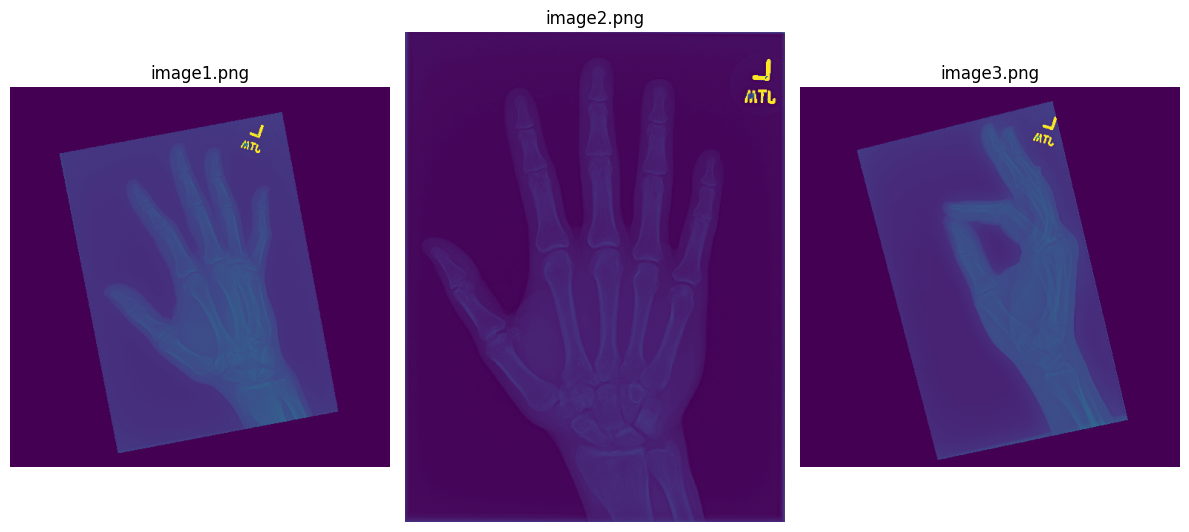


--- Displaying images for Bone: XR_HUMERUS ---
Positive Studies for XR_HUMERUS:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HUMERUS/patient00051/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HUMERUS/patient00051/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HUMERUS/patient00147/study1_positive/image1.png')


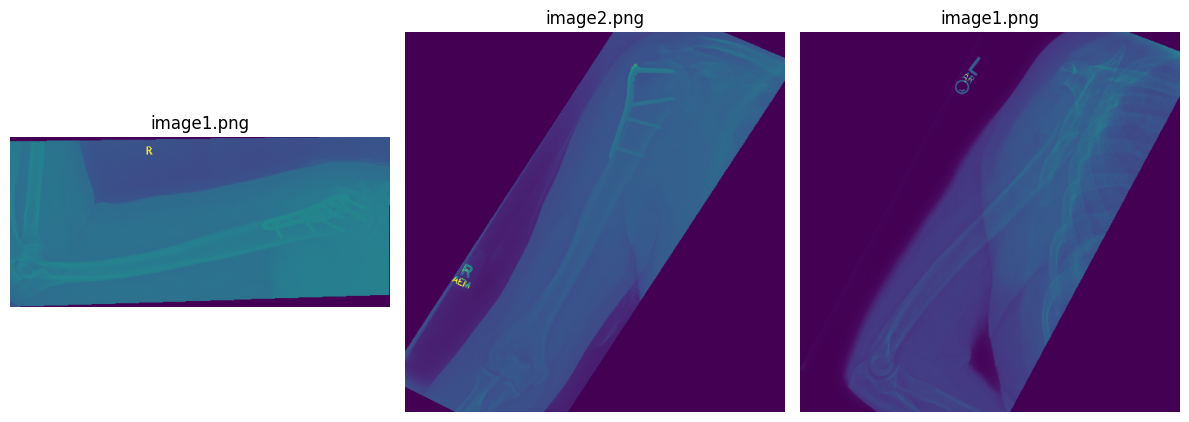

Negative Studies for XR_HUMERUS:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HUMERUS/patient00058/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HUMERUS/patient00058/study1_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_HUMERUS/patient00077/study1_negative/image1.png')


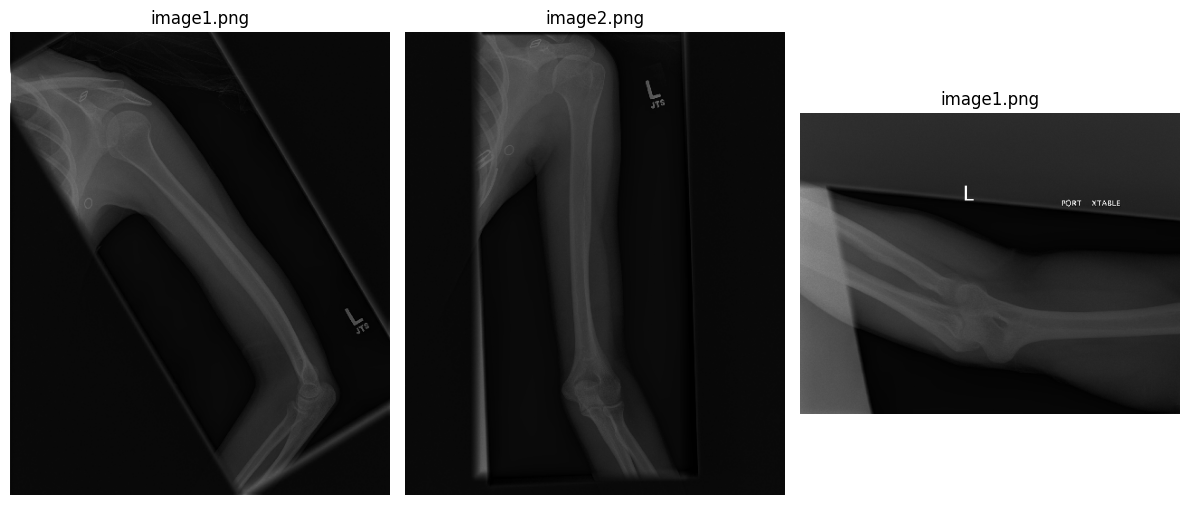


--- Displaying images for Bone: XR_SHOULDER ---
Positive Studies for XR_SHOULDER:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image3.png')


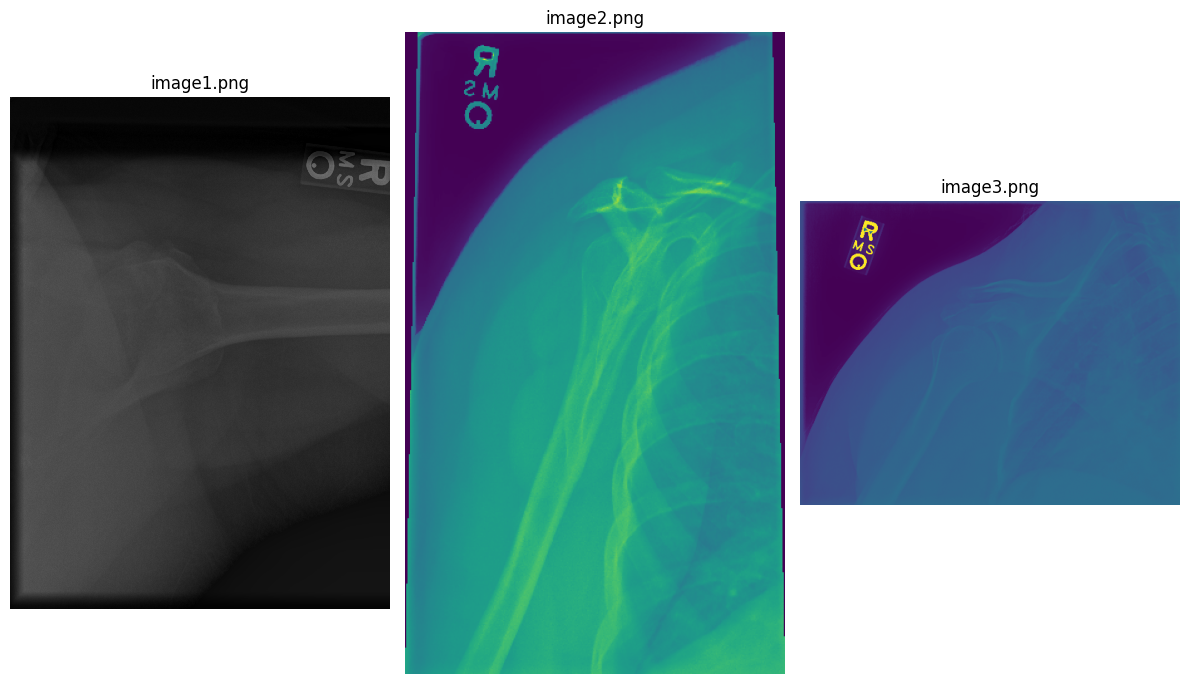

Negative Studies for XR_SHOULDER:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient00007/study2_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient00007/study2_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient00007/study2_negative/image3.png')


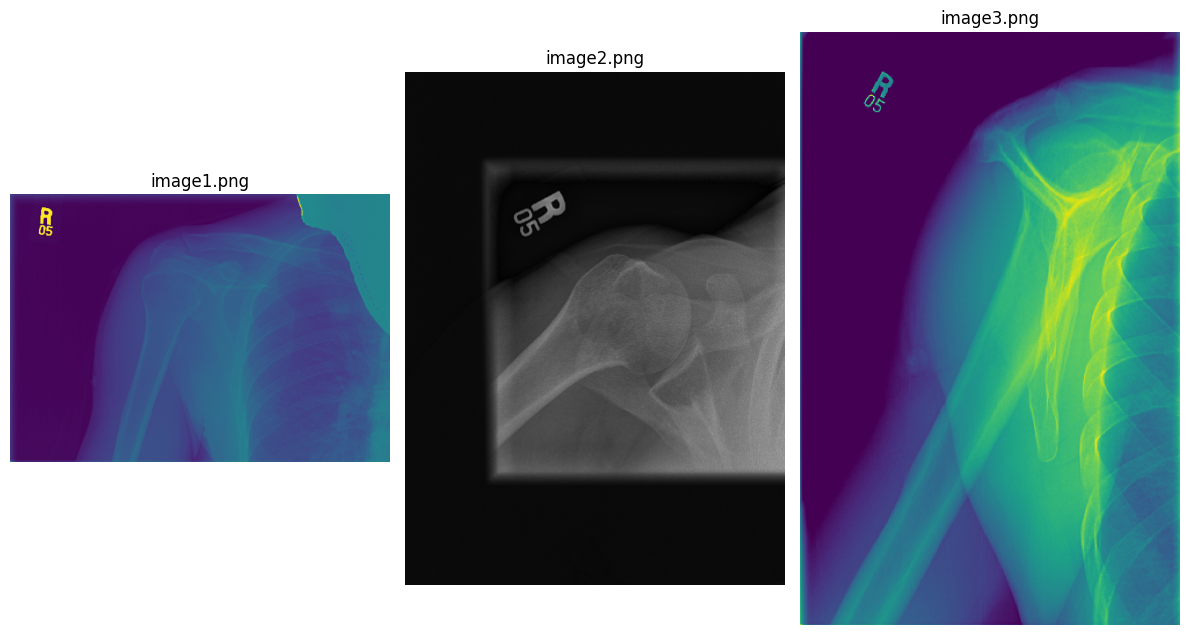


--- Displaying images for Bone: XR_WRIST ---
Positive Studies for XR_WRIST:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_WRIST/patient00006/study1_positive/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_WRIST/patient00006/study1_positive/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_WRIST/patient00006/study1_positive/image3.png')


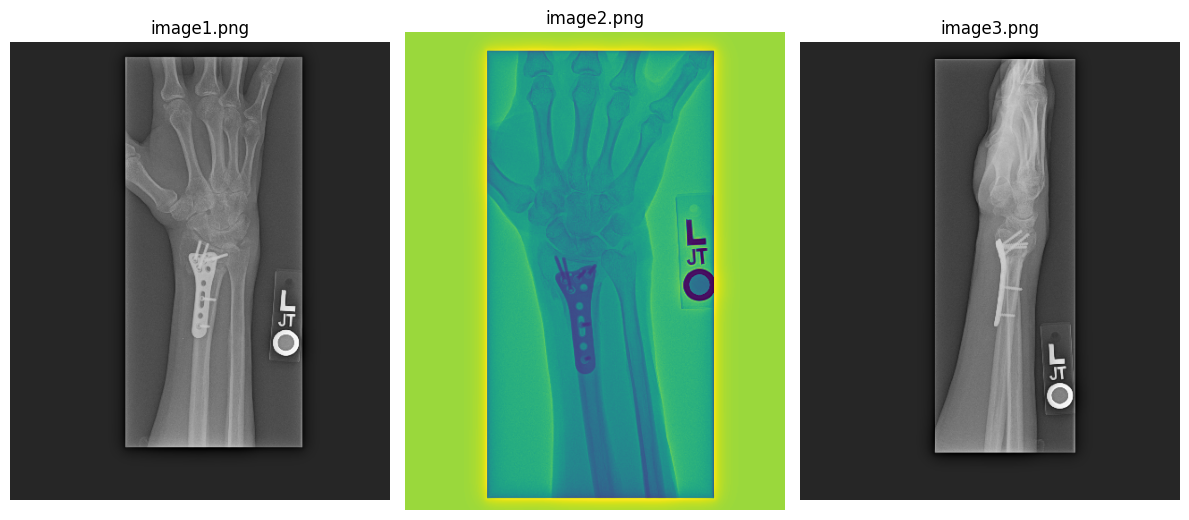

Negative Studies for XR_WRIST:
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_WRIST/patient00012/study1_negative/image1.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_WRIST/patient00012/study1_negative/image2.png')
Text(0.5, 1.0, '/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_WRIST/patient00012/study1_negative/image3.png')


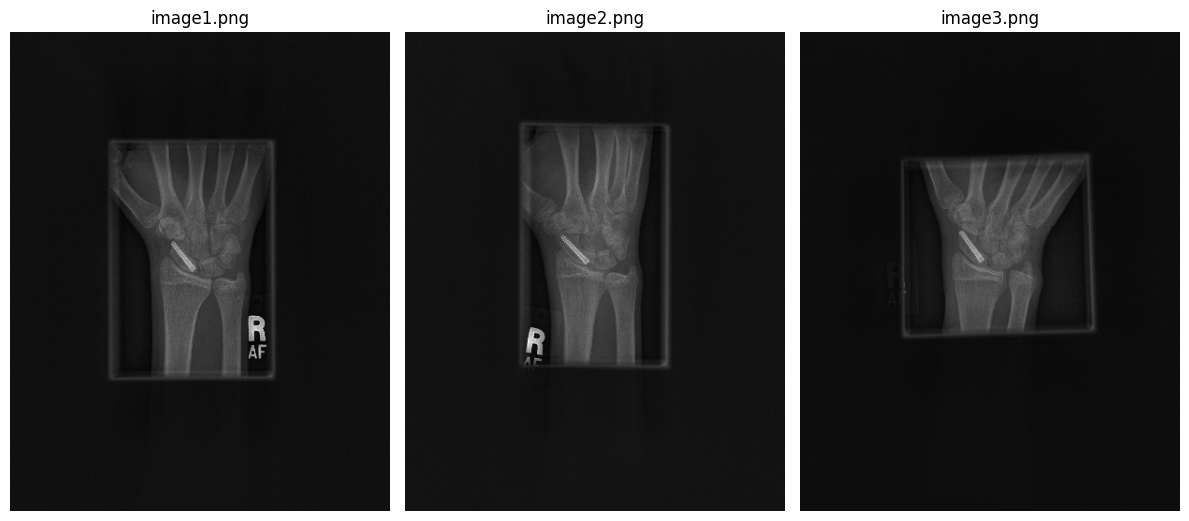

In [10]:
import os

unique_bones = df_MURA_fn_train['Bone'].unique()

for bone in unique_bones:
    print(f"\n--- Displaying images for Bone: {bone} ---")

    # Positive studies
    positive_images_df = df_MURA_fn_train[(df_MURA_fn_train['Bone'] == bone) & (df_MURA_fn_train['Label'] == 'positive')]
    positive_image_paths = [os.path.join(path, 'MURA-v1.1', p.replace("\\", "/")) for p in positive_images_df['path'].head(3)]
    if positive_image_paths:
        print(f"Positive Studies for {bone}:")
        plot_images(positive_image_paths, rows=1, cols=3)
    else:
        print(f"No positive images found for {bone}.")

    # Negative studies
    negative_images_df = df_MURA_fn_train[(df_MURA_fn_train['Bone'] == bone) & (df_MURA_fn_train['Label'] == 'negative')]
    negative_image_paths = [os.path.join(path, 'MURA-v1.1', p.replace("\\", "/")) for p in negative_images_df['path'].head(3)]
    if negative_image_paths:
        print(f"Negative Studies for {bone}:")
        plot_images(negative_image_paths, rows=1, cols=3)
    else:
        print(f"No negative images found for {bone}.")

In [ ]:
!pip install kagglehub
!pip install torch torchvision
import kagglehub
import os
import csv
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader # Import Dataset from torch.utils.data
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
#CHanged to load required file while training
import kagglehub
import os
import csv
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# %%
import os

path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11")

class MuraDataSet(Dataset):
    def __init__(self, dataset_path: str):
        """
        Pairs of images and labels (int) for classification

        """
        self.transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        # Add this line to ensure 3 channels for normalization
        transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

        LABEL_NAMES=['negative','positive']
        self.samples = []

        with open(Path(dataset_path), newline="") as f:
            print(f"{dataset_path=}")
            reader = csv.reader(f)
            next(reader) # Skip header row
            for _,_,filepath,_,_,_,_,_,label in reader:
                image_full_path = os.path.join(path,'MURA-v1.1', filepath.replace("\\", "/"))
                if label in LABEL_NAMES:
                    label_id = LABEL_NAMES.index(label)
                    self.samples.append((image_full_path, label_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label_id = self.samples[idx]
        image = Image.open(Path(image_path)).convert('L') # Ensure grayscale before possible 3-channel conversion
        # Apply the transform to resize and convert to tensor
        image = self.transform(image)
        return image, label_id

def load_data(dataset_path: str, num_workers: int = 0, batch_size: int = 128, shuffle: bool = False) -> DataLoader:
    dataset = MuraDataSet(dataset_path)

    return DataLoader(dataset, num_workers=num_workers, batch_size=batch_size, shuffle=shuffle, drop_last=True,pin_memory=True)

Using Colab cache for faster access to the 'mura-v11' dataset.


#Swin Transformer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_model():
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
    # The o/p of the Swin backbone's feature extractor, before the *original* timm head's pooling/flattening,
    # for a 224x224 input, is effectively (batch_size, 7, 7, 768).
    # When replacing `model.head` directly, it appears this 4D tensor is passed to our new head.
    n_features = model.head.in_features # This will be 768

    model.head = nn.Sequential(
        nn.Flatten(), # Flattens (batch_size, 7, 7, 768) to (batch_size, 7*7*768)
        nn.Linear(n_features * 7 * 7, 1), # Applies linear transformation to the flattened features
        nn.Sigmoid() # Activation for binary classification
    )
    return model.to(device)

model = build_model()
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

### Training the Model

Now that the data loaders, model, and training functions are defined, let's add a training loop to train the Swin Transformer model.

In [ ]:
import numpy as np
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device).view(-1, 1).float()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = (outputs > 0.5).int() # Convert probabilities to binary predictions
        correct_predictions += (preds == labels.int()).sum().item()
        total_samples += labels.size(0)

    accuracy = correct_predictions / total_samples
    return total_loss / len(dataloader), accuracy

def validate_one_epoch(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).view(-1, 1).float()
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = (outputs > 0.5).int()
            correct_predictions += (preds == labels.int()).sum().item()
            total_samples += labels.size(0)

    accuracy = correct_predictions / total_samples
    return total_loss / len(dataloader), accuracy

# After training, get all predictions for evaluation
def evaluate(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # with open(fn, 'wb') as f:
  #    f.write(uploaded[fn])

print("File upload complete.")

Saving swin_mura_model_25ep.pth to swin_mura_model_25ep.pth
User uploaded file "swin_mura_model_25ep.pth" with length 110297660 bytes
File upload complete.


In [ ]:
# To continue training for additional epoch load the existing model
import torch

# Re-instantiate the model with the same architecture
model = build_model()

# Load the saved state dictionary
model.load_state_dict(torch.load('swin_mura_model_25ep.pth'))
model.to(device)

print("Model loaded successfully from swin_mura_model_25ep.pth.")

Model loaded successfully from swin_mura_model_25ep.pth.


In [ ]:
num_epochs = 10   # You can adjust the number of epochs

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Create the training DataLoader
train_csv_path = os.path.join(path, "MURA_fn_train.csv")
train_dataloader = load_data(train_csv_path, batch_size=32, shuffle=True)

# Create the validation DataLoader
dev_csv_path = os.path.join(path, "MURA_fn_dev.csv")
dev_dataloader = load_data(dev_csv_path, batch_size=32, shuffle=False)

print(f"Starting training for {num_epochs} epochs...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_dataloader, criterion, optimizer)
    val_loss, val_acc = validate_one_epoch(model, dev_dataloader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("Training complete.")
# Save the updated model after additional training
torch.save(model.state_dict(), 'swin_mura_model_25ep.pth')
print("Model saved to swin_mura_model_25ep.pth")

dataset_path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA_fn_train.csv'
dataset_path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA_fn_dev.csv'
Starting training for 10 epochs...
Epoch 1/10, Train Loss: 0.7492, Train Acc: 0.5014, Val Loss: 0.7566, Val Acc: 0.4837
Epoch 2/10, Train Loss: 0.7514, Train Acc: 0.4997, Val Loss: 0.7499, Val Acc: 0.5041
Epoch 3/10, Train Loss: 0.7512, Train Acc: 0.4972, Val Loss: 0.7615, Val Acc: 0.4872
Epoch 4/10, Train Loss: 0.7508, Train Acc: 0.4994, Val Loss: 0.7543, Val Acc: 0.4875
Epoch 5/10, Train Loss: 0.7530, Train Acc: 0.4939, Val Loss: 0.7520, Val Acc: 0.5027
Epoch 6/10, Train Loss: 0.7546, Train Acc: 0.4943, Val Loss: 0.7569, Val Acc: 0.4878
Epoch 7/10, Train Loss: 0.7511, Train Acc: 0.4982, Val Loss: 0.7529, Val Acc: 0.5043
Epoch 8/10, Train Loss: 0.7532, Train Acc: 0.4954, Val Loss: 0.7532, Val Acc: 0.5035
Epoch 9/10, Train Loss: 0.7511, Train Acc: 0.4957, Val Loss: 0.7530, Val Ac

In [ ]:
training_output = """
Epoch 1/10, Train Loss: 0.7492, Train Acc: 0.5014, Val Loss: 0.7566, Val Acc: 0.4837
Epoch 2/10, Train Loss: 0.7514, Train Acc: 0.4997, Val Loss: 0.7499, Val Acc: 0.5041
Epoch 3/10, Train Loss: 0.7512, Train Acc: 0.4972, Val Loss: 0.7615, Val Acc: 0.4872
Epoch 4/10, Train Loss: 0.7508, Train Acc: 0.4994, Val Loss: 0.7543, Val Acc: 0.4875
Epoch 5/10, Train Loss: 0.7530, Train Acc: 0.4939, Val Loss: 0.7520, Val Acc: 0.5027
Epoch 6/10, Train Loss: 0.7546, Train Acc: 0.4943, Val Loss: 0.7569, Val Acc: 0.4878
Epoch 7/10, Train Loss: 0.7511, Train Acc: 0.4982, Val Loss: 0.7529, Val Acc: 0.5043
Epoch 8/10, Train Loss: 0.7532, Train Acc: 0.4954, Val Loss: 0.7532, Val Acc: 0.5035
Epoch 9/10, Train Loss: 0.7511, Train Acc: 0.4957, Val Loss: 0.7530, Val Acc: 0.4929
Epoch 10/10, Train Loss: 0.7521, Train Acc: 0.4956, Val Loss: 0.7562, Val Acc: 0.4959
"""

epochs = []
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for line in training_output.strip().split('\n'):
    parts = line.split(',')

    # Extract epoch number
    epoch_str = parts[0].split(' ')[1].split('/')[0]
    epochs.append(int(epoch_str))

    # Extract values and convert to float
    train_loss = float(parts[1].split(':')[1].strip())
    train_acc = float(parts[2].split(':')[1].strip())
    val_loss = float(parts[3].split(':')[1].strip())
    val_acc = float(parts[4].split(':')[1].strip())

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

print(f"Epochs: {epochs}")
print(f"Train Losses: {train_losses}")
print(f"Train Accuracies: {train_accuracies}")
print(f"Validation Losses: {val_losses}")
print(f"Validation Accuracies: {val_accuracies}")

Epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Train Losses: [0.7492, 0.7514, 0.7512, 0.7508, 0.753, 0.7546, 0.7511, 0.7532, 0.7511, 0.7521]
Train Accuracies: [0.5014, 0.4997, 0.4972, 0.4994, 0.4939, 0.4943, 0.4982, 0.4954, 0.4957, 0.4956]
Validation Losses: [0.7566, 0.7499, 0.7615, 0.7543, 0.752, 0.7569, 0.7529, 0.7532, 0.753, 0.7562]
Validation Accuracies: [0.4837, 0.5041, 0.4872, 0.4875, 0.5027, 0.4878, 0.5043, 0.5035, 0.4929, 0.4959]


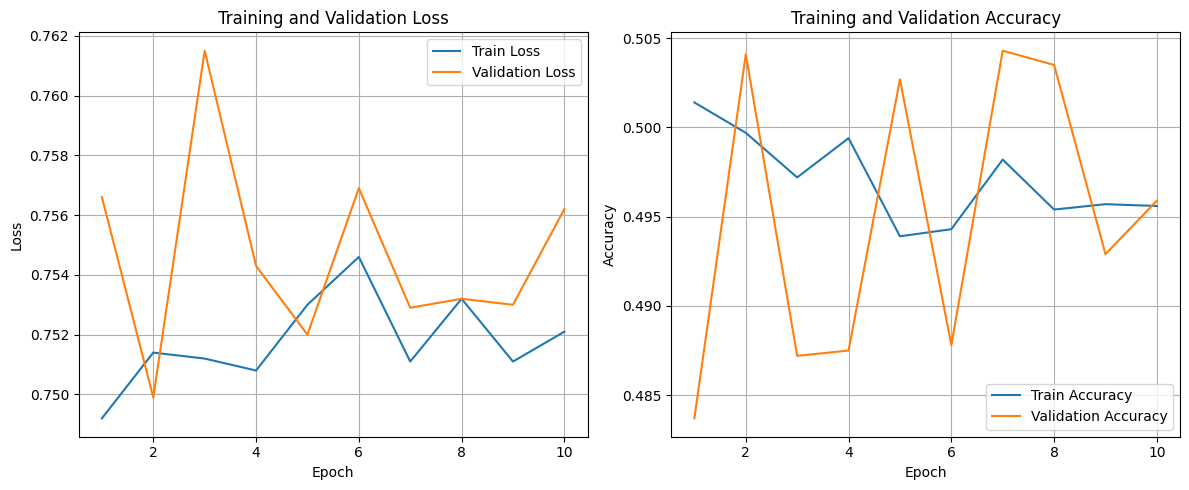

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Save the Trained Model

In [ ]:
# Save the updated model after additional training
torch.save(model.state_dict(), 'swin_mura_model_25ep.pth')
print("Model saved to swin_mura_model_25ep.pth")

Model saved to swin_mura_model_25ep.pth


dataset_path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA_fn_dev.csv'


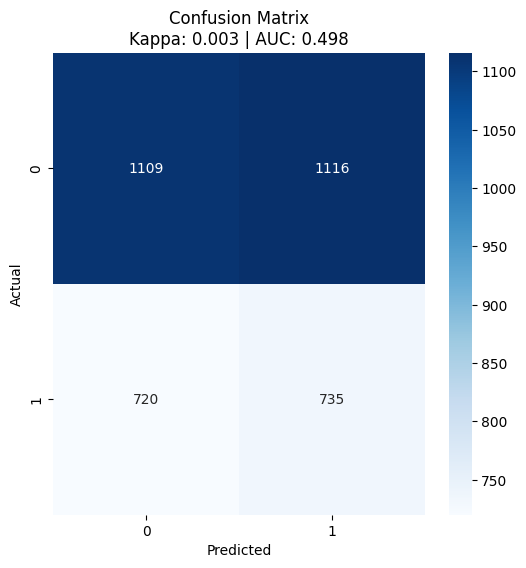

              precision    recall  f1-score   support

           0       0.61      0.50      0.55      2225
           1       0.40      0.51      0.44      1455

    accuracy                           0.50      3680
   macro avg       0.50      0.50      0.50      3680
weighted avg       0.52      0.50      0.51      3680



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, roc_auc_score, confusion_matrix, classification_report
import os # Import os for path operations


dev_csv_path = os.path.join(path, "MURA_fn_dev.csv")
dev_dataloader = load_data(dev_csv_path, batch_size=32, shuffle=False)

# Obtain labels and probabilities from the evaluate function
labels, probs = evaluate(model, dev_dataloader)

preds = (probs > 0.5).astype(int)

# 1. Cohen's Kappa
kappa = cohen_kappa_score(labels, preds)
# 2. ROC-AUC
auc = roc_auc_score(labels, probs)
# 3. Confusion Matrix
cm = confusion_matrix(labels, preds)

# Plotting Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nKappa: {kappa:.3f} | AUC: {auc:.3f}')
plt.show()

print(classification_report(labels, preds))

In [ ]:

%ls
!git status

# Be careful not to "git add *" since there are datasets and logs
!git add aih-hrp/*.*
!git config --global user.email "GITHUB_EMAIL"
!git config --global user.name "GITHUB_USER"
!git commit -m "update"
!git push origin main
#!git add *.*
#!git add Classifier*.th
!git add swin_mura_model_10ep.pth
!git commit -m "Added trained model file"
!git push origin main

Classifier_Muradataset_20250413_1epoch.th  mura_resnet18_for_ELBOW_DS.pt
Classifier.th                              mura_resnet18.pt
metrics_train.json                         swin_mura_model_10ep.pth
model.py                                   train.py
mura_dataset                               utils.py
mura_dataset.py
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: pathspec 'aih-hrp/*.*' did not match any files
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
To https://github.com/shaanmsai/dl-hw.git
 ! [rejected]          main -> main (fetch first)
error: failed to push some refs to 'https://github.com/shaanmsai/dl-hw.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing

In [ ]:
from google.colab import files

files.download('swin_mura_model_25ep.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

dataset_path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA_fn_dev.csv'


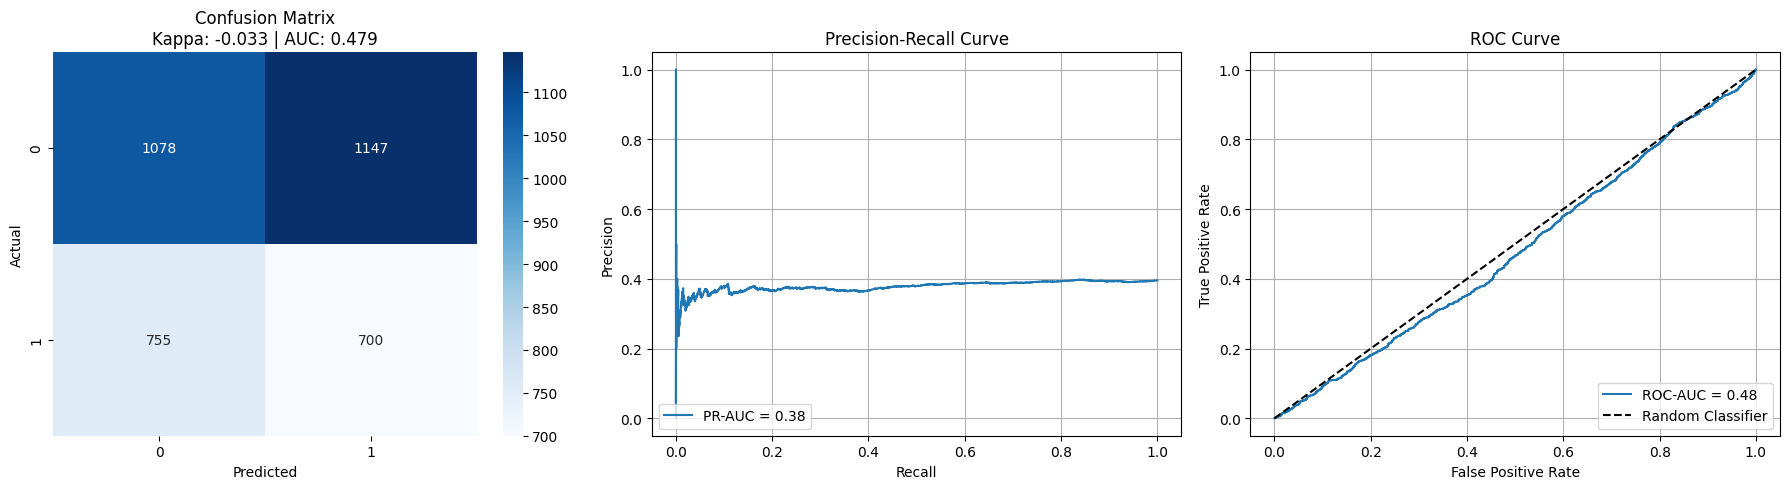


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.48      0.53      2225
           1       0.38      0.48      0.42      1455

    accuracy                           0.48      3680
   macro avg       0.48      0.48      0.48      3680
weighted avg       0.51      0.48      0.49      3680



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc
import os

# Using MURA_fn_dev.csv for evaluation data
dev_csv_path = os.path.join(path, "MURA_fn_dev.csv")
dev_dataloader = load_data(dev_csv_path, batch_size=32, shuffle=False)

# Obtain labels and probabilities
labels, probs = evaluate(model, dev_dataloader)

# Convert probabilities to binary predictions for metrics like confusion matrix and precision/recall
preds = (probs > 0.5).astype(int)

# 1. Cohen's Kappa
kappa = cohen_kappa_score(labels, preds)
# 2. ROC-AUC
auc_roc = roc_auc_score(labels, probs)
# 3. Confusion Matrix - Re-define cm here
cm = confusion_matrix(labels, preds)

# Plotting Confusion Matrix
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nKappa: {kappa:.3f} | AUC: {auc_roc:.3f}')

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(labels, probs)
pr_auc = auc(recall, precision)

plt.subplot(1, 3, 2)
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

# 4. ROC Curve
fpr, tpr, _ = roc_curve(labels, probs)

plt.subplot(1, 3, 3)
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc_roc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(labels, preds))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate overall accuracy
overall_accuracy = accuracy_score(labels, preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# Calculate precision, recall, and F1-score for each class

precision = precision_score(labels, preds, average=None)
recall = recall_score(labels, preds, average=None)
f1 = f1_score(labels, preds, average=None)

print(f"\nPrecision per class (0, 1): {precision}")
print(f"Recall (Sensitivity) per class (0, 1): {recall}")
print(f"F1-score per class (0, 1): {f1}")

print("\nClassification Report:")
print(classification_report(labels, preds))

Overall Accuracy: 0.4832

Precision per class (0, 1): [0.58810693 0.37899296]
Recall (Sensitivity) per class (0, 1): [0.48449438 0.48109966]
F1-score per class (0, 1): [0.53129621 0.42398546]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.48      0.53      2225
           1       0.38      0.48      0.42      1455

    accuracy                           0.48      3680
   macro avg       0.48      0.48      0.48      3680
weighted avg       0.51      0.48      0.49      3680



In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
import os

# Ensure 'path' variable is defined from kagglehub.dataset_download in previous cells
# Ensure 'model' variable is defined from build_model() in previous cells
# Ensure 'load_data' function is defined in previous cells
# Using MURA_fn_dev.csv for evaluation data
dev_csv_path = os.path.join(path, "MURA_fn_dev.csv")
dev_dataloader = load_data(dev_csv_path, batch_size=32, shuffle=False)

# Obtain labels and probabilities from the evaluate function
labels, probs = evaluate(model, dev_dataloader)

# Convert probabilities to binary predictions
preds = (probs > 0.5).astype(int)

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(labels, preds)

print(f"Cohen's Kappa: {kappa:.4f}")

dataset_path='/kaggle/input/mura-v11/MURA_fn_dev.csv'
Cohen's Kappa: 0.0133
